# 💎 Diamond Price Analysis
## Data Mining Final Project | CRISP-DM Methodology
---
**Dataset:** Diamonds Dataset (Kaggle) | 53,940 records  
**Team:** Mustafa Elsherif  and rawda attia  
**Goal:** Analyze diamond pricing using clustering, regression, anomaly detection & classification

In [156]:
# ============================================================
# IMPORTS
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine Learning - Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning - Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Machine Learning - Classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

# Machine Learning - Anomaly Detection
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM

# Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (mean_squared_error, r2_score,
                             classification_report, confusion_matrix)

# Warnings
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")

 All libraries imported successfully!


---
## 1. Business Understanding

**Problem:** Diamond prices vary widely — what drives the price of a diamond?

**Business Questions:**
- Can we predict a diamond's price based on its features?
- Are there natural groups/segments of diamonds?
- Which diamonds are unusually priced (anomalies)?
- Can we classify diamond cut quality automatically?

**Success Criteria:**
- Regression R² > 0.90
- Clear and meaningful customer segments
- Detect outliers with explainable reasons
- Classification accuracy > 85%

---
## 2. Data Understanding

In [157]:
# ============================================================
# LOAD DATA
# ============================================================

import os
DATA_PATH = 'C:/Users/musta/dm-diamonds-analysis/data/'

df = pd.read_csv(DATA_PATH + 'diamonds.csv')

# Drop useless column
df = df.drop(columns=['Unnamed: 0'])

print(f" Dataset loaded successfully!")
print(f" Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n--- First 5 rows ---")
df.head()

 Dataset loaded successfully!
 Shape: 53940 rows × 10 columns

--- First 5 rows ---


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [158]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

print("--- Dataset Info ---")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\n--- Column Types ---")
print(df.dtypes)
print(f"\n--- Missing Values ---")
print(df.isnull().sum())
print(f"\n--- Basic Statistics ---")
df.describe()


--- Dataset Info ---
Rows: 53940
Columns: 10

--- Column Types ---
carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

--- Missing Values ---
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

--- Basic Statistics ---


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [159]:
# ============================================================
# CHECK DUPLICATES
# ============================================================

duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
print(f"Duplicate percentage: {duplicates/len(df)*100:.2f}%")

if duplicates > 0:
    print(f"\nRemoving {duplicates} duplicate rows...")
    df = df.drop_duplicates()
    print(f"Clean shape: {df.shape}")
else:
    print("No duplicates found ")

Duplicate rows: 146
Duplicate percentage: 0.27%

Removing 146 duplicate rows...
Clean shape: (53794, 10)


### Dataset Overview Summary
**Size:** 53,794 diamonds × 10 core features (after removing Unnamed: 0 and 146 duplicate rows)

**Numerical Features (7):**
- carat — diamond weight (0.2 to 5.01)
- depth — total depth percentage (43 to 79)
- table — width of top of diamond (43 to 95)
- price — price in USD (326 to 18,823) ← target variable
- x, y, z — length, width, depth in mm

**Categorical Features (3):**
- cut — quality of the cut (Fair, Good, Very Good, Premium, Ideal)
- color — diamond color (D=best to J=worst)
- clarity — diamond clarity (IF=best to I1=worst)

**Data Quality (initial check):**
- No missing values in any column
- Zero values found in x, y, z → impossible for real diamonds
- Extreme outliers found in y and z → will be handled in Data Preparation
- Price is right-skewed → log transformation will be applied in modeling

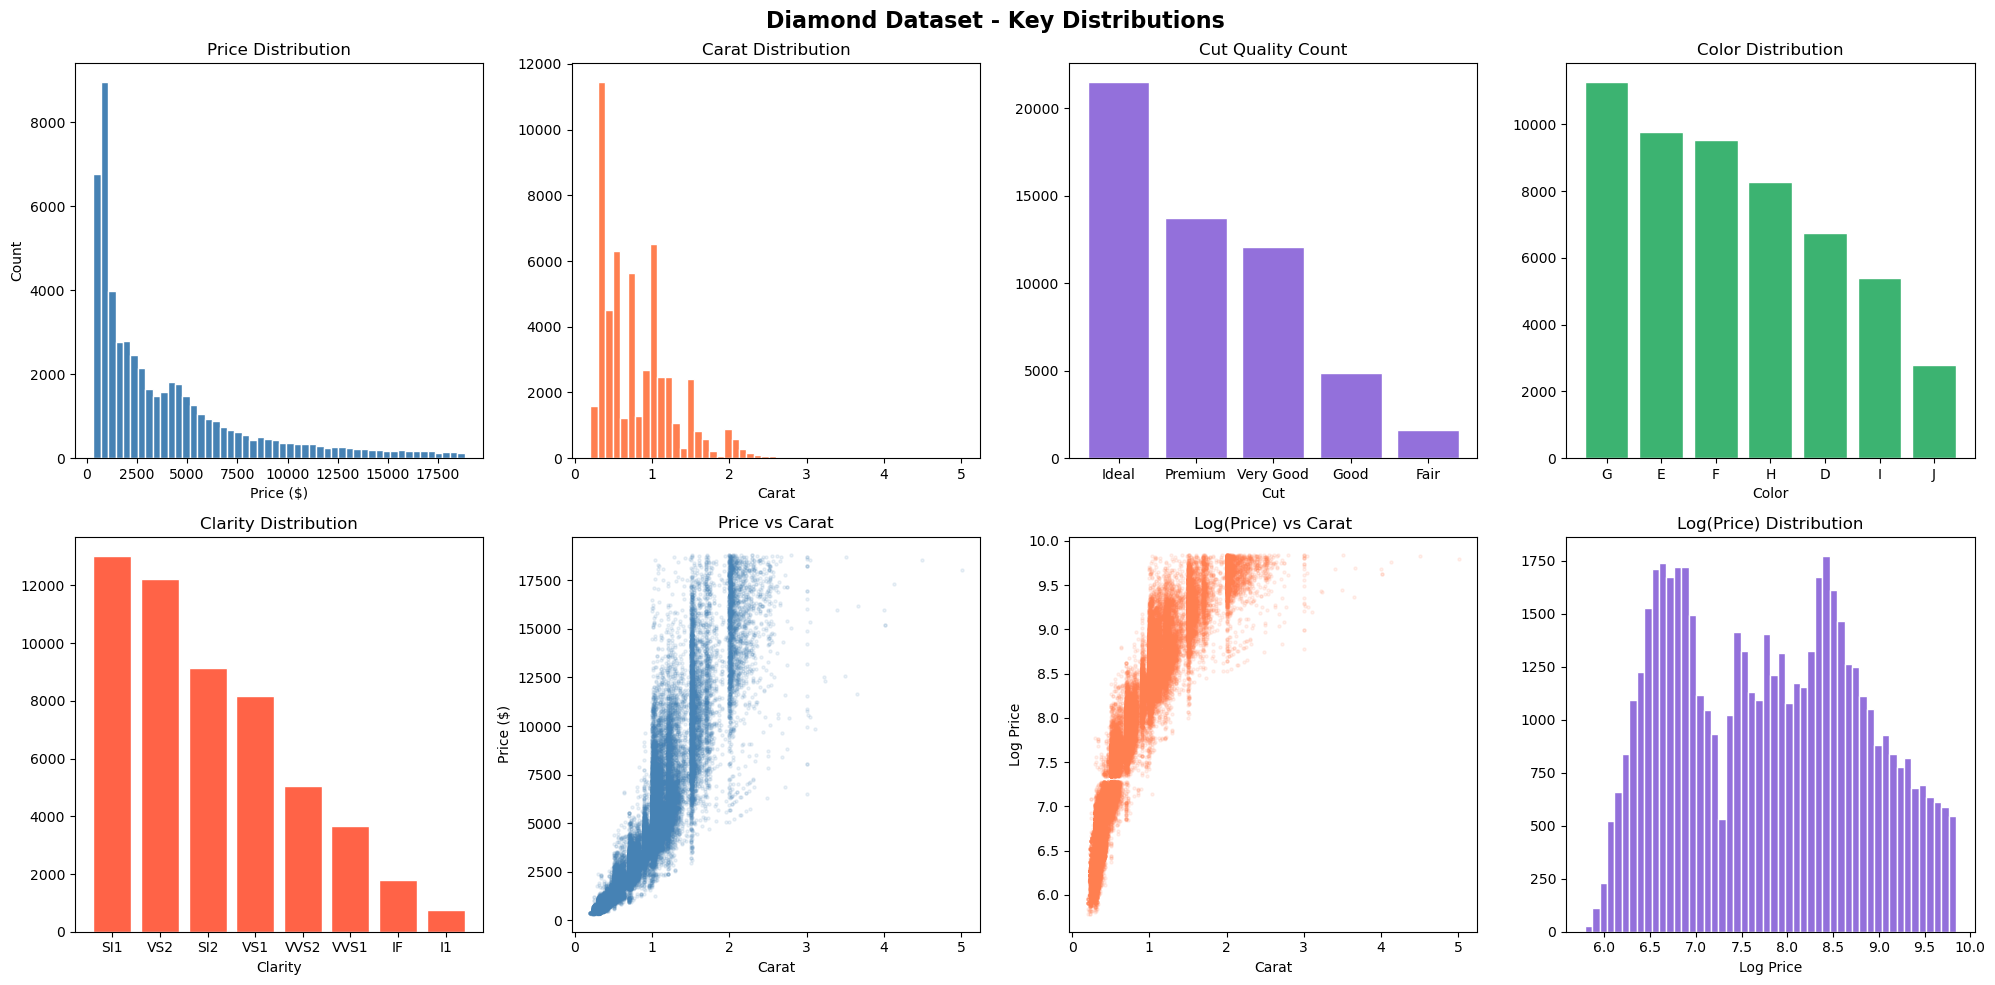

 Plots saved!


In [160]:
# ============================================================
# DATA VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Diamond Dataset - Key Distributions', fontsize=16, fontweight='bold')

# 1. Price distribution
axes[0,0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price ($)')
axes[0,0].set_ylabel('Count')

# 2. Carat distribution
axes[0,1].hist(df['carat'], bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('Carat Distribution')
axes[0,1].set_xlabel('Carat')

# 3. Cut counts
cut_counts = df['cut'].value_counts()
axes[0,2].bar(cut_counts.index, cut_counts.values, color='mediumpurple', edgecolor='white')
axes[0,2].set_title('Cut Quality Count')
axes[0,2].set_xlabel('Cut')

# 4. Color counts
color_counts = df['color'].value_counts()
axes[0,3].bar(color_counts.index, color_counts.values, color='mediumseagreen', edgecolor='white')
axes[0,3].set_title('Color Distribution')
axes[0,3].set_xlabel('Color')

# 5. Clarity counts
clarity_counts = df['clarity'].value_counts()
axes[1,0].bar(clarity_counts.index, clarity_counts.values, color='tomato', edgecolor='white')
axes[1,0].set_title('Clarity Distribution')
axes[1,0].set_xlabel('Clarity')

# 6. Price vs Carat
axes[1,1].scatter(df['carat'], df['price'], alpha=0.1, color='steelblue', s=5)
axes[1,1].set_title('Price vs Carat')
axes[1,1].set_xlabel('Carat')
axes[1,1].set_ylabel('Price ($)')

# 7. Log Price vs Carat - shows true relationship
axes[1,2].scatter(df['carat'], np.log(df['price']), alpha=0.1, color='coral', s=5)
axes[1,2].set_title('Log(Price) vs Carat')
axes[1,2].set_xlabel('Carat')
axes[1,2].set_ylabel('Log Price')

# 8. Price distribution - log scale
axes[1,3].hist(np.log(df['price']), bins=50, color='mediumpurple', edgecolor='white')
axes[1,3].set_title('Log(Price) Distribution')
axes[1,3].set_xlabel('Log Price')

plt.tight_layout()
plt.savefig(DATA_PATH + 'eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plots saved!")

### Key Observations from Distributions

**Price & Carat:**
- Price is heavily right-skewed — most diamonds are under $2,500, few are very expensive
- Carat is also right-skewed — most diamonds are under 1 carat
- Price vs Carat shows a non-linear relationship with visible clusters at 0.5, 1.0, 1.5, 2.0 carat (people prefer round numbers)
- Log(Price) vs Carat becomes much cleaner and more linear → we will use log transformation in regression

**Cut, Color, Clarity:**
- Ideal cut is the most common (~40% of diamonds)
- Color G is the most common, J is the rarest
- SI1 and VS2 are the most common clarity grades
- IF (best clarity) is the rarest

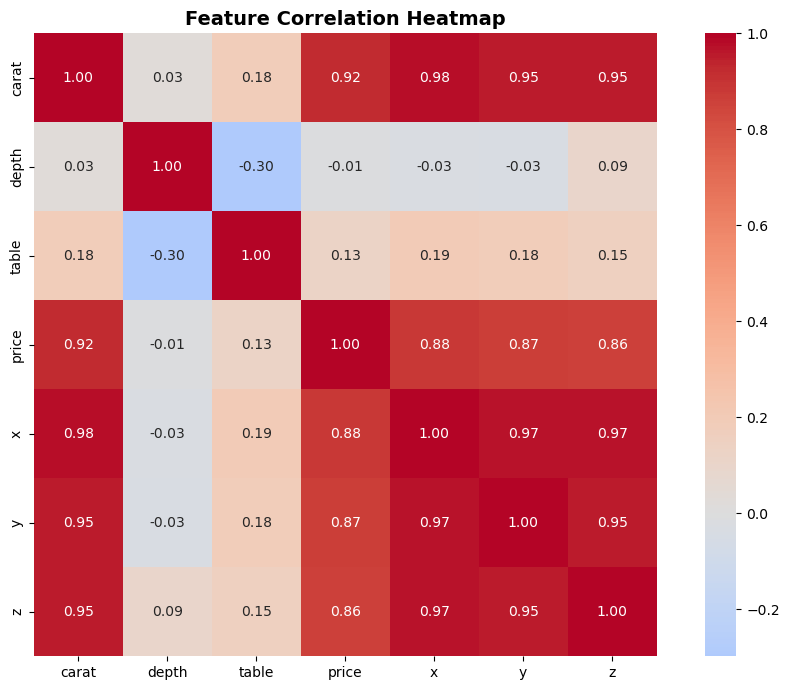

 Correlation heatmap saved!


In [161]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

plt.figure(figsize=(10, 7))
numeric_cols = df.select_dtypes(include=np.number)
correlation = numeric_cols.corr()

sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PATH + 'correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Correlation heatmap saved!")

### Key Observations from Correlation Heatmap

**Strong positive correlation with price:**
- carat → price = 0.92 (strongest feature)
- x → price = 0.88
- y → price = 0.87
- z → price = 0.86
- Note: x, y, z are highly correlated with carat (they represent physical size)

**Weak correlation with price:**
- depth → price = -0.01 (almost no effect)
- table → price = 0.13 (very weak)

**Key insight:**
Carat is the dominant predictor of price.
depth and table will likely have low importance in our models.
x, y, z may cause multicollinearity with carat — we will handle this in Data Preparation.

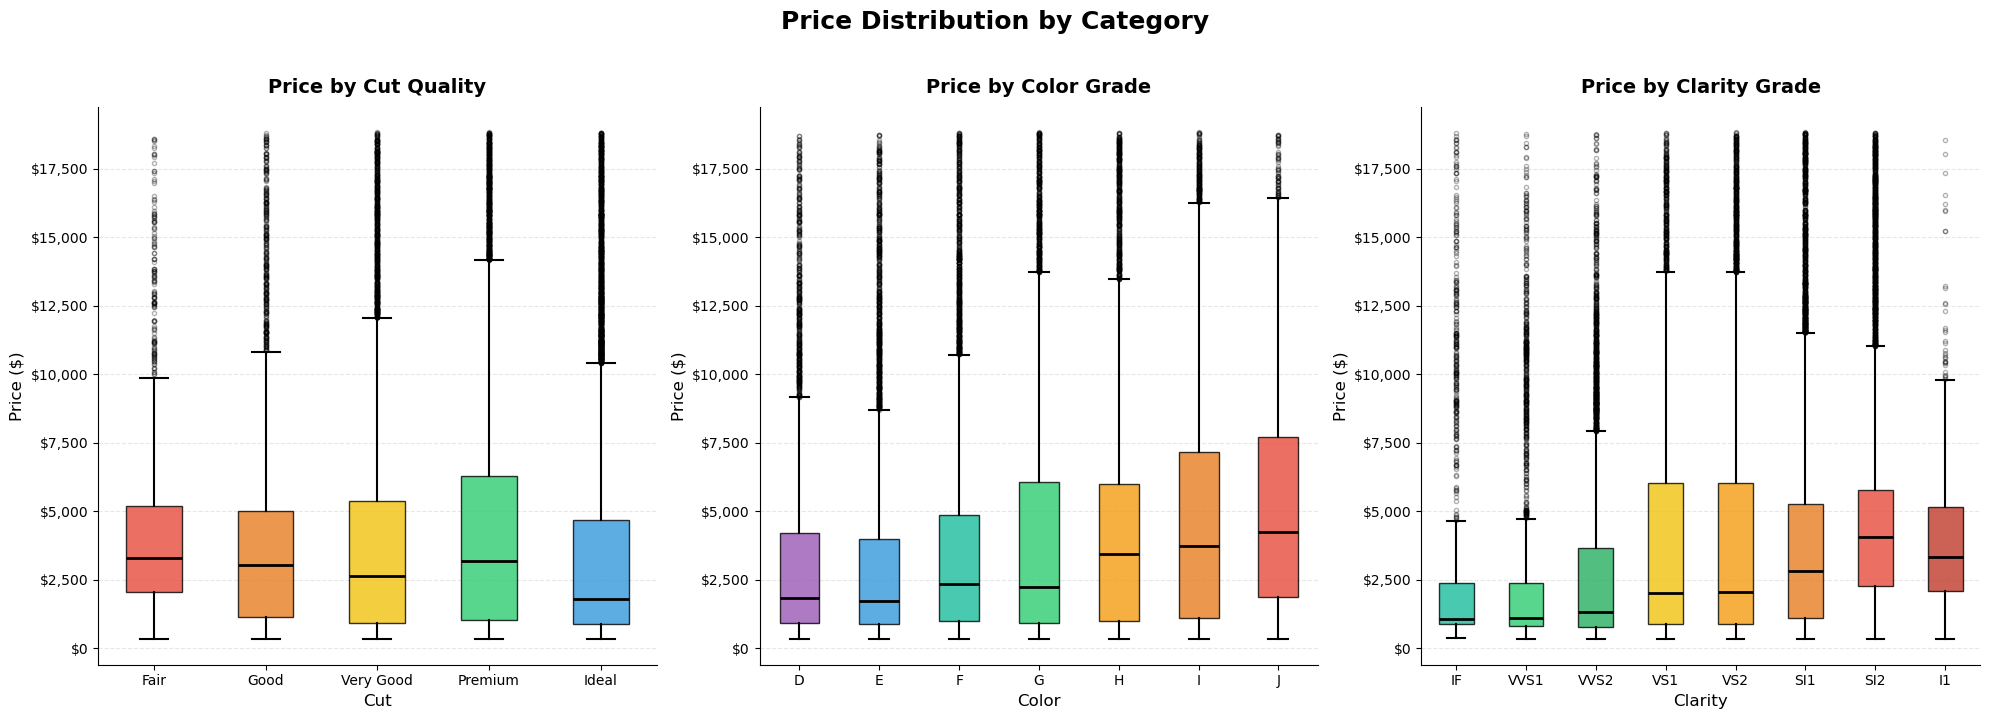

 Box plots saved!


In [162]:
# ============================================================
# BOX PLOTS - Price Distribution by Category
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Price Distribution by Category', fontsize=18, fontweight='bold', y=1.02)

cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity_order = ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

colors_cut     = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db']
colors_color   = ['#9b59b6','#3498db','#1abc9c','#2ecc71','#f39c12','#e67e22','#e74c3c']
colors_clarity = ['#1abc9c','#2ecc71','#27ae60','#f1c40f','#f39c12','#e67e22','#e74c3c','#c0392b']

# --- Plot function ---
def styled_boxplot(ax, data_list, labels, colors, title, xlabel):
    bp = ax.boxplot(data_list, labels=labels, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markersize=3, alpha=0.3))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Price ($)', fontsize=12)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 1. Price by Cut
styled_boxplot(axes[0],
               [df[df['cut']==c]['price'].values for c in cut_order],
               cut_order, colors_cut,
               'Price by Cut Quality', 'Cut')

# 2. Price by Color
styled_boxplot(axes[1],
               [df[df['color']==c]['price'].values for c in color_order],
               color_order, colors_color,
               'Price by Color Grade', 'Color')

# 3. Price by Clarity
styled_boxplot(axes[2],
               [df[df['clarity']==c]['price'].values for c in clarity_order],
               clarity_order, colors_clarity,
               'Price by Clarity Grade', 'Clarity')

plt.tight_layout()
plt.savefig(DATA_PATH + 'boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Box plots saved!")

### Key Observations from Box Plots

**Price by Cut — Surprising finding:**
- Ideal cut (best quality) has LOWER median price than Premium
- Reason: Ideal cut diamonds tend to come in smaller carats
- This confirms that carat dominates price more than cut quality

**Price by Color — Surprising finding:**
- D (best color) has LOWER median price than J (worst color)
- Same reason: lower color grade diamonds tend to be larger in carat
- This is called the "carat size confounding effect"

**Price by Clarity — Same pattern:**
- IF (best clarity) has the LOWEST median price
- SI2 has higher median price due to larger carat sizes

**Outliers:**
- All categories show many outliers above the upper whisker
- These are very large/expensive diamonds and are expected in the data
- They will be kept as they represent real high-value diamonds

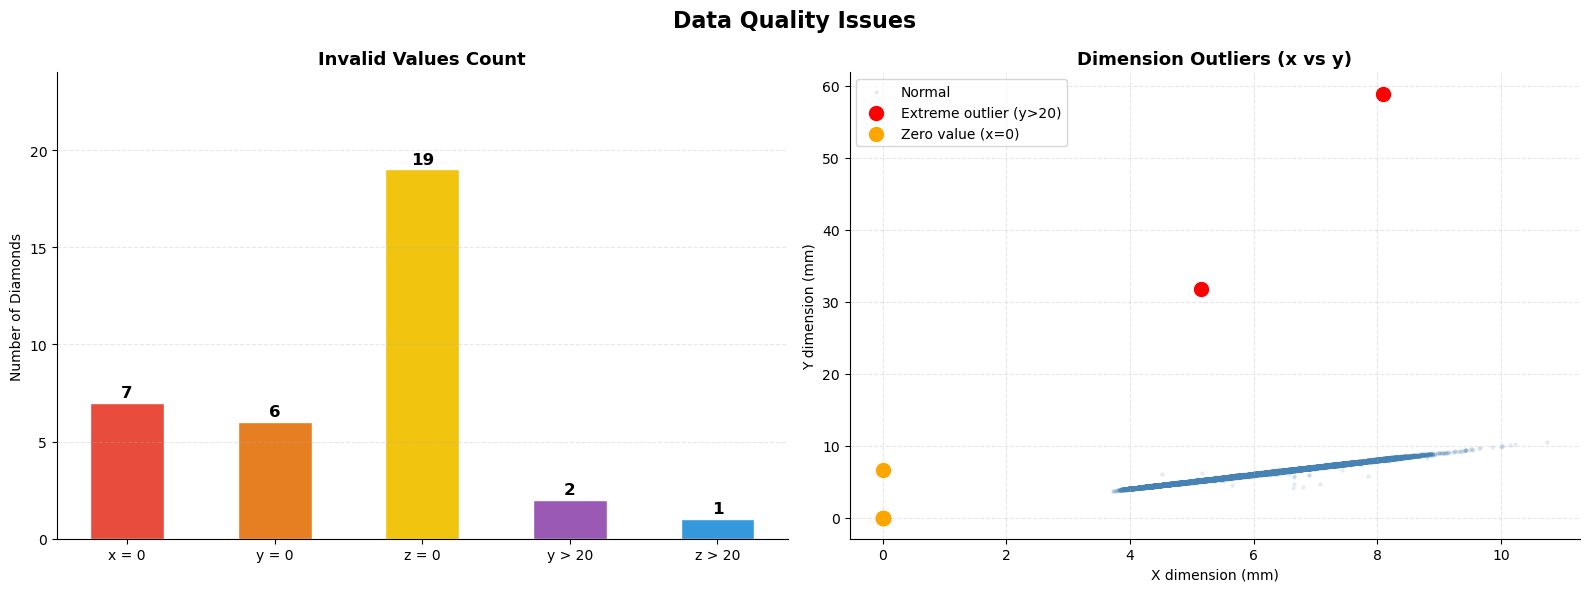

DATA QUALITY ISSUES SUMMARY
  x = 0 (impossible dimension): 7 diamonds
  y = 0 (impossible dimension): 6 diamonds
  z = 0 (impossible dimension): 19 diamonds
  y > 20mm (extreme outlier):   2 diamonds
  z > 20mm (extreme outlier):   1 diamonds
→ These will be removed in Data Preparation


In [163]:
# ============================================================
# ZERO VALUES & OUTLIERS DETECTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Data Quality Issues', fontsize=16, fontweight='bold')

# --- Left: Zero values bar chart ---
zero_counts = {
    'x = 0': df[df['x'] == 0].shape[0],
    'y = 0': df[df['y'] == 0].shape[0],
    'z = 0': df[df['z'] == 0].shape[0],
    'y > 20': df[df['y'] > 20].shape[0],
    'z > 20': df[df['z'] > 20].shape[0]
}

bars = axes[0].bar(zero_counts.keys(), zero_counts.values(),
                   color=['#e74c3c','#e67e22','#f1c40f','#9b59b6','#3498db'],
                   edgecolor='white', width=0.5)

for bar, val in zip(bars, zero_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontsize=12, fontweight='bold')

axes[0].set_title('Invalid Values Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Diamonds')
axes[0].set_ylim(0, max(zero_counts.values()) + 5)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Right: Scatter showing extreme outliers ---
axes[1].scatter(df['x'], df['y'], alpha=0.1, s=5, color='steelblue', label='Normal')
axes[1].scatter(df[df['y'] > 20]['x'], df[df['y'] > 20]['y'],
                color='red', s=100, zorder=5, label='Extreme outlier (y>20)')
axes[1].scatter(df[df['x'] == 0]['x'], df[df['x'] == 0]['y'],
                color='orange', s=100, zorder=5, label='Zero value (x=0)')
axes[1].set_title('Dimension Outliers (x vs y)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('X dimension (mm)')
axes[1].set_ylabel('Y dimension (mm)')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(DATA_PATH + 'data_quality.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary ---
print("=" * 45)
print("DATA QUALITY ISSUES SUMMARY")
print("=" * 45)
print(f"  x = 0 (impossible dimension): {df[df['x']==0].shape[0]} diamonds")
print(f"  y = 0 (impossible dimension): {df[df['y']==0].shape[0]} diamonds")
print(f"  z = 0 (impossible dimension): {df[df['z']==0].shape[0]} diamonds")
print(f"  y > 20mm (extreme outlier):   {df[df['y']>20].shape[0]} diamonds")
print(f"  z > 20mm (extreme outlier):   {df[df['z']>20].shape[0]} diamonds")
print("=" * 45)
print("→ These will be removed in Data Preparation")

### Key Observations from Data Quality Analysis

**Zero Values (impossible dimensions):**
- 7 diamonds have x = 0
- 6 diamonds have y = 0
- 19 diamonds have z = 0
- Note: some diamonds have multiple zero dimensions simultaneously
- Total unique diamonds with zero dimensions: 19 (after deduplication)
- A real diamond cannot have zero dimensions → these are data entry errors

**Extreme Outliers:**
- 2 diamonds have y > 20mm (one has y = 58.9mm — impossible for a diamond)
- 1 diamond has z > 20mm (z = 31.8mm — impossible for a diamond)
- Normal diamond dimensions are between 3mm and 11mm

**Action Plan:**
- All zero-dimension diamonds will be removed in Data Preparation (19 unique rows)
- All extreme outliers (y > 20, z > 20) will be removed in Data Preparation (3 rows)
- Total rows to remove: 22 out of 53,794 (less than 0.1% of data)
- This will not affect our analysis significantly

---
##  Technique Selection Rationale

### Why these techniques for diamonds?

| Technique | Algorithm | Reason |
|-----------|-----------|--------|
| Clustering | K-Means | Group diamonds into natural price/quality segments |
| Regression | Polynomial + Ridge | Price has non-linear relationship with carat (confirmed in EDA) |
| Anomaly Detection | One-Class SVM (+ PCA preprocessing) | Detect mispriced diamonds and invalid dimensions found in EDA |
| Classification | Random Forest | Classify cut quality, handles 5 classes and gives feature importance |

### Why not other techniques?
- Linear Regression alone - too simple, relationship is non-linear
- DBSCAN - varying density in diamonds data, K-Means gives cleaner segments
- Logistic Regression - 5 cut classes with complex boundaries, Random Forest handles better
- Simple SVM - One-Class SVM is specifically designed for anomaly detection
- PCA alone - only reduces dimensions, does not detect anomalies by itself

---
## CRISP-DM Plan

| Phase | Activities | Techniques |
|-------|-----------|------------|
| Business Understanding | Define problem & goals | — |
| Data Understanding | EDA, distributions, correlations | Pandas, Seaborn |
| Data Preparation | Clean, encode, scale | LabelEncoder, StandardScaler |
| Modelling | Apply 4 mining techniques | KMeans, LinearRegression, PCA, RandomForest |
| Evaluation | Metrics per technique | R², Silhouette, Accuracy |
| Deployment | Interactive dashboard | Streamlit |

---
## 3. Data Preparation

### Original Dataset: 53,794 diamonds × 10 columns
After dropping Unnamed:0 and removing 146 duplicate rows → 10 core columns:
carat, cut, color, clarity, depth, table, price, x, y, z

---

### Step 1 - Remove Zero Dimensions
**Columns affected:** x, y, z

A real diamond must have physical dimensions.
Any diamond with x=0, y=0, or z=0 is a data entry error → removed.

- Removed: 19 diamonds with zero dimensions
- Remaining: 53,775 diamonds

---

### Step 2 - Remove Extreme Outliers
**Columns affected:** y, z

Normal diamond size is between 3mm and 11mm.
Any diamond with y>20mm or z>20mm is physically impossible → removed.

- Removed: 3 diamonds (y=58.9mm, z=31.8mm)
- Remaining: 53,772 diamonds ← final clean dataset

---

### Step 3 - Create log(price)
**Column added:** log_price

Price is heavily right-skewed (most diamonds cheap, few very expensive).
Log transformation makes the distribution normal and the relationship with carat more linear.
This new column will be used as the target in regression instead of raw price.

- log_price = log(price)

---

### Step 4 - Encode Categorical Features
**Columns added:** cut_encoded, color_encoded, clarity_encoded

Models only understand numbers, not text.
We use ordered encoding because quality order matters — higher number = better quality.

| Column | Original Values | Encoded Values |
|--------|----------------|----------------|
| cut | Fair, Good, Very Good, Premium, Ideal | 0, 1, 2, 3, 4 |
| color | J, I, H, G, F, E, D | 0, 1, 2, 3, 4, 5, 6 |
| clarity | I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF | 0, 1, 2, 3, 4, 5, 6, 7 |

---

### Step 5 - Scale Numerical Features
**Columns scaled:** carat, depth, table, x, y, z, cut_encoded, color_encoded, clarity_encoded

Features have very different ranges:
- carat: 0.2 to 5.0
- price: 326 to 18,823

StandardScaler transforms each feature to have mean=0 and std=1.
This prevents the model from being biased toward large numbers.
Used in: Clustering and Anomaly Detection (not regression)

---

### Final Dataset Summary
| | Before | After |
|--|--------|-------|
| Rows | 53,794 | 53,772 |
| Core columns | 10 | 10 |
| Added columns | 0 | 4 (log_price, cut_encoded, color_encoded, clarity_encoded) |
| Scaled version | - | df_scaled (for clustering & anomaly detection) |

In [164]:
# ============================================================
# DATA PREPARATION
# ============================================================

print(f"Original shape: {df.shape}")

# --- Step 1: Remove zero dimensions ---
df_clean = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]
print(f"After removing zero dimensions: {df_clean.shape}")

# --- Step 2: Remove extreme outliers ---
df_clean = df_clean[(df_clean['y'] < 20) & (df_clean['z'] < 20)]
print(f"After removing extreme outliers: {df_clean.shape}")

# --- Step 3: Create log(price) ---
df_clean = df_clean.copy()
df_clean['log_price'] = np.log(df_clean['price'])

# --- Step 4: Encode categorical features (ordered) ---
cut_order     = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order   = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

df_clean['cut_encoded']     = df_clean['cut'].map({v: i for i, v in enumerate(cut_order)})
df_clean['color_encoded']   = df_clean['color'].map({v: i for i, v in enumerate(color_order)})
df_clean['clarity_encoded'] = df_clean['clarity'].map({v: i for i, v in enumerate(clarity_order)})

# --- Step 5: Scale numerical features ---
scaler = StandardScaler()
scale_cols = ['carat', 'depth', 'table', 'x', 'y', 'z',
              'cut_encoded', 'color_encoded', 'clarity_encoded']

df_scaled = df_clean.copy()
df_scaled[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

# Remove EDA helper columns
df_clean = df_clean.drop(columns=['price_per_carat', 'carat_group'], errors='ignore')

print(f"\n Data preparation complete!")
print(f"Final clean shape: {df_clean.shape}")
print(f"\n--- Encoding Sample ---")
df_clean[['cut','cut_encoded','color','color_encoded','clarity','clarity_encoded']].head(3)

Original shape: (53794, 10)
After removing zero dimensions: (53775, 10)
After removing extreme outliers: (53772, 10)

 Data preparation complete!
Final clean shape: (53772, 14)

--- Encoding Sample ---


,cut,cut_encoded,color,color_encoded,clarity,clarity_encoded
0,Ideal,4,E,5,SI2,1
1,Premium,3,E,5,SI1,2
2,Good,1,E,5,VS1,4


---
## 4. Modelling

All four required techniques are applied following CRISP-DM methodology.
Each section includes: model setup, hyperparameter choices, results, and visualizations.

---
### 4.1 Clustering — K-Means

**Goal:** Group diamonds into natural market segments based on physical and quality features.

**Features used:** carat, depth, table, x, y, z, cut_encoded, color_encoded, clarity_encoded (all scaled)

**Method:** Elbow Method + Silhouette Score to find optimal k

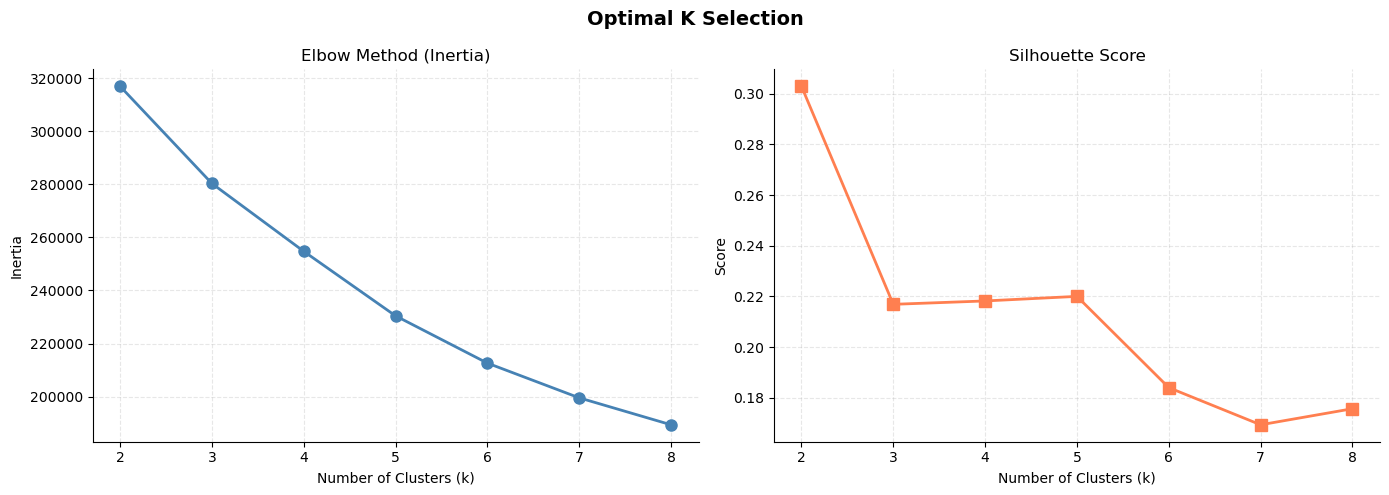

Silhouette Scores:
  k=2: 0.3030 ← Best
  k=3: 0.2169
  k=4: 0.2182
  k=5: 0.2200
  k=6: 0.1840
  k=7: 0.1693
  k=8: 0.1757


In [165]:
# ============================================================
# CLUSTERING — ELBOW + SILHOUETTE TO FIND OPTIMAL K
# ============================================================

features_cluster = ['carat', 'depth', 'table', 'x', 'y', 'z',
                    'cut_encoded', 'color_encoded', 'clarity_encoded']

X_cluster = df_scaled[features_cluster].values

inertias, silhouettes = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal K Selection', fontsize=14, fontweight='bold')

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(list(K_range), silhouettes, marker='s', color='coral', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(DATA_PATH + 'clustering_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

print('Silhouette Scores:')
for k, s in zip(K_range, silhouettes):
    marker = ' ← Best' if s == max(silhouettes) else ''
    print(f'  k={k}: {s:.4f}{marker}')

=== Cluster Profile ===
         Count  Avg_Price  Avg_Carat  Median_Price  Top_Cut Top_Color  \
cluster                                                                 
0         6565    3317.08       0.78        2788.0  Premium         E   
1        22698    1090.38       0.40         882.0    Ideal         G   
2         8147   10855.27       1.65       10656.0  Premium         I   
3        16362    4670.65       0.94        4249.0    Ideal         G   

        Top_Clarity  
cluster              
0               SI1  
1               VS2  
2               SI2  
3               SI1  


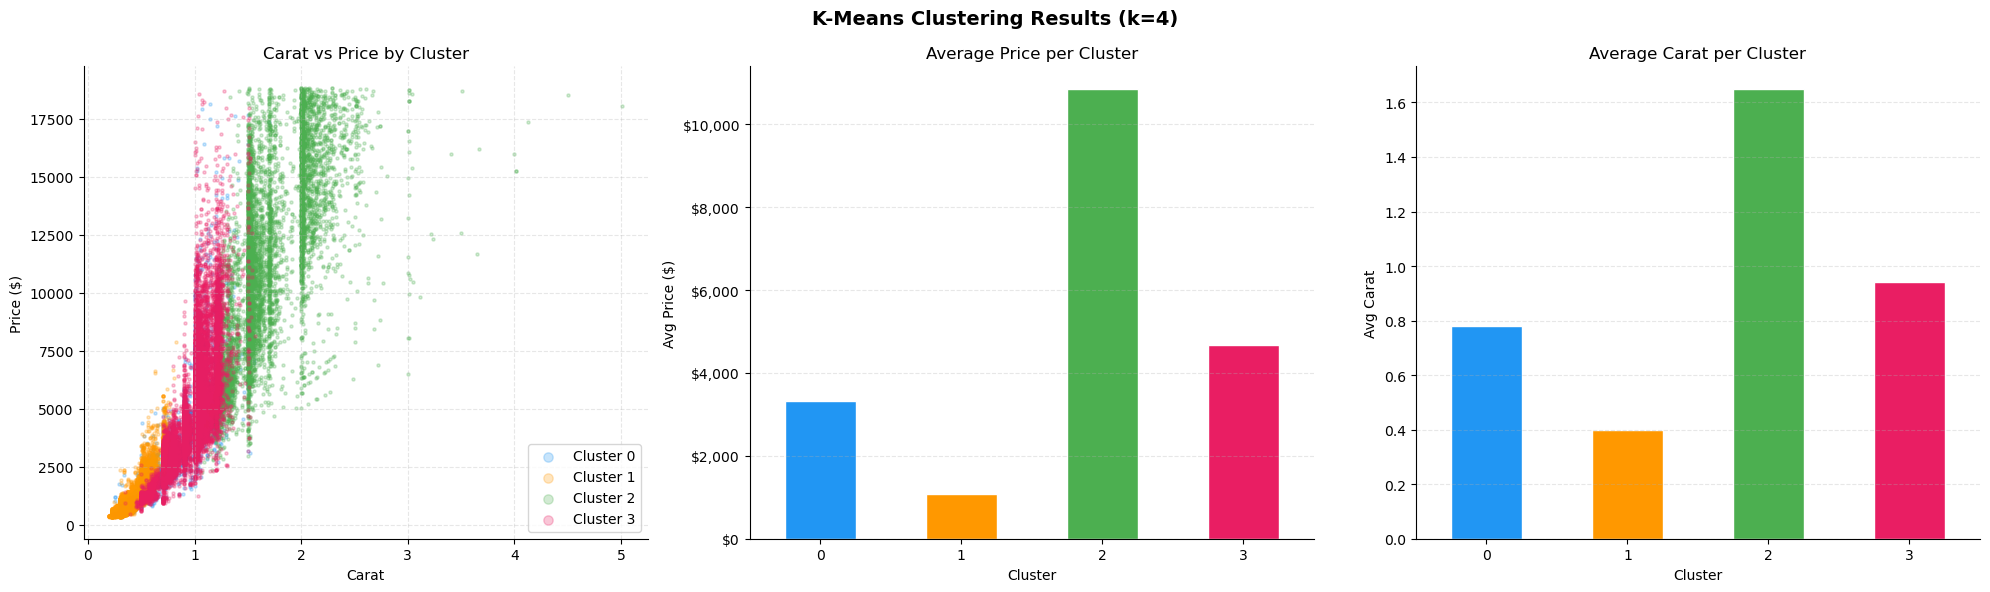


 Final Silhouette Score (k=4): 0.2182
   Total diamonds clustered: 53,772


In [166]:
# ============================================================
# CLUSTERING — FINAL K-MEANS
# ============================================================

# k=2 has best silhouette mathematically
# but 2 segments are too broad for business use
# k=4 gives 4 meaningful market segments with acceptable silhouette score

BEST_K = 4

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df_clean['cluster'] = km_final.fit_predict(X_cluster)

# --- Cluster Profile ---
cluster_profile = df_clean.groupby('cluster').agg(
    Count        = ('price', 'size'),
    Avg_Price    = ('price', 'mean'),
    Avg_Carat    = ('carat', 'mean'),
    Median_Price = ('price', 'median'),
    Top_Cut      = ('cut', lambda x: x.mode()[0]),
    Top_Color    = ('color', lambda x: x.mode()[0]),
    Top_Clarity  = ('clarity', lambda x: x.mode()[0]),
).round(2)

print('=== Cluster Profile ===')
print(cluster_profile)

# --- Visualizations ---
palette = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'K-Means Clustering Results (k={BEST_K})', fontsize=14, fontweight='bold')

# 1. Carat vs Price colored by cluster
for c in range(BEST_K):
    mask = df_clean['cluster'] == c
    axes[0].scatter(df_clean.loc[mask, 'carat'], df_clean.loc[mask, 'price'],
                    alpha=0.25, s=5, color=palette[c], label=f'Cluster {c}')
axes[0].set_xlabel('Carat')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Carat vs Price by Cluster')
axes[0].legend(markerscale=3)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# 2. Avg Price per Cluster
cluster_profile['Avg_Price'].plot(kind='bar', ax=axes[1], color=palette, edgecolor='white')
axes[1].set_title('Average Price per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Avg Price ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3, linestyle='--', axis='y')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# 3. Avg Carat per Cluster
cluster_profile['Avg_Carat'].plot(kind='bar', ax=axes[2], color=palette, edgecolor='white')
axes[2].set_title('Average Carat per Cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Avg Carat')
axes[2].tick_params(axis='x', rotation=0)
axes[2].grid(True, alpha=0.3, linestyle='--', axis='y')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(DATA_PATH + 'clustering_results.png', dpi=150, bbox_inches='tight')
plt.show()

sil_final = silhouette_score(X_cluster, df_clean['cluster'], sample_size=5000, random_state=42)
print(f'\n Final Silhouette Score (k={BEST_K}): {sil_final:.4f}')
print(f'   Total diamonds clustered: {len(df_clean):,}')

### Clustering Results & Observations

**Why k=4 instead of k=2?**
- k=2 had the best Silhouette Score (0.3030) mathematically
- But 2 segments are too broad for business use
- k=4 gives 4 meaningful market segments with acceptable Silhouette Score (0.2182)

**4 Natural Diamond Segments identified:**

| Cluster | Count | Avg Carat | Avg Price | Top Cut | Market Label |
|---------|-------|-----------|-----------|---------|--------------|
| 0 | 6,565 | 0.78 | $3,317 | Premium | Mid-range |
| 1 | 22,698 | 0.40 | $1,090 | Ideal | Budget / Entry-level |
| 2 | 8,147 | 1.65 | $10,855 | Premium | Luxury |
| 3 | 16,362 | 0.94 | $4,671 | Ideal | Upper Mid-range |

**Key findings:**
- Carat is the dominant factor separating clusters — confirms EDA findings
- Cluster 1 is the largest (22,698 diamonds) — most diamonds are affordable entry-level
- Cluster 2 is the luxury segment — largest carat (1.65) and highest price ($10,855)
- Top Cut is Ideal or Premium across all clusters — quality is consistent
- Final Silhouette Score = 0.2182 — acceptable for this dataset size
- Total diamonds clustered: 53,772

**Business value:**
Retailers can use these 4 segments to target marketing and pricing strategies per customer type.

---
### 4.2 Regression — Predicting Diamond Price

**Goal:** Predict diamond price from its features.

**Target:** log(price) — price is right-skewed, log transform makes relationship more linear (confirmed in EDA)

**Features used:** carat, depth, table, x, y, z, cut_encoded, color_encoded, clarity_encoded (all scaled)

**Models compared:**
1. Linear Regression — baseline
2. Ridge Regression — regularized linear, prevents overfitting
3. Polynomial Regression (degree=2) + Ridge — captures non-linear carat relationship

In [167]:
# ============================================================
# REGRESSION — Linear, Ridge, Polynomial + Ridge
# TARGET = log(price)
# ============================================================

features_reg = ['carat', 'depth', 'table', 'x', 'y', 'z',
                'cut_encoded', 'color_encoded', 'clarity_encoded']

X_reg = df_scaled[features_reg].values
y_reg = df_clean['log_price'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

# --- 1. Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr    = lr.predict(X_test)
r2_lr        = r2_score(y_test, y_pred_lr)
rmse_lr      = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# --- 2. Ridge Regression ---
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
r2_ridge     = r2_score(y_test, y_pred_ridge)
rmse_ridge   = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

# --- 3. Polynomial Regression (degree=2) + Ridge ---
poly         = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)
poly_ridge   = Ridge(alpha=1.0)
poly_ridge.fit(X_train_poly, y_train)
y_pred_pr    = poly_ridge.predict(X_test_poly)
r2_pr        = r2_score(y_test, y_pred_pr)
rmse_pr      = np.sqrt(mean_squared_error(y_test, y_pred_pr))

# --- Results ---
print('=' * 55)
print('REGRESSION RESULTS  (Target = log price)')
print('=' * 55)
print(f"{'Model':<30} {'R²':>8} {'RMSE':>10}")
print('-' * 55)
print(f"{'Linear Regression':<30} {r2_lr:>8.4f} {rmse_lr:>10.4f}")
print(f"{'Ridge Regression':<30} {r2_ridge:>8.4f} {rmse_ridge:>10.4f}")
print(f"{'Polynomial (deg=2) + Ridge':<30} {r2_pr:>8.4f} {rmse_pr:>10.4f}")
print('=' * 55)
best = max([(r2_lr,'Linear'),(r2_ridge,'Ridge'),(r2_pr,'Polynomial+Ridge')], key=lambda x: x[0])
print(f'\n Best model: {best[1]}  |  R² = {best[0]:.4f}')
print(f'   Business goal (R² > 0.90): {" MET" if best[0] >= 0.90 else " NOT MET"}')

REGRESSION RESULTS  (Target = log price)
Model                                R²       RMSE
-------------------------------------------------------
Linear Regression                0.9782     0.1491
Ridge Regression                 0.9782     0.1491
Polynomial (deg=2) + Ridge       0.9858     0.1203

 Best model: Polynomial+Ridge  |  R² = 0.9858
   Business goal (R² > 0.90):  MET


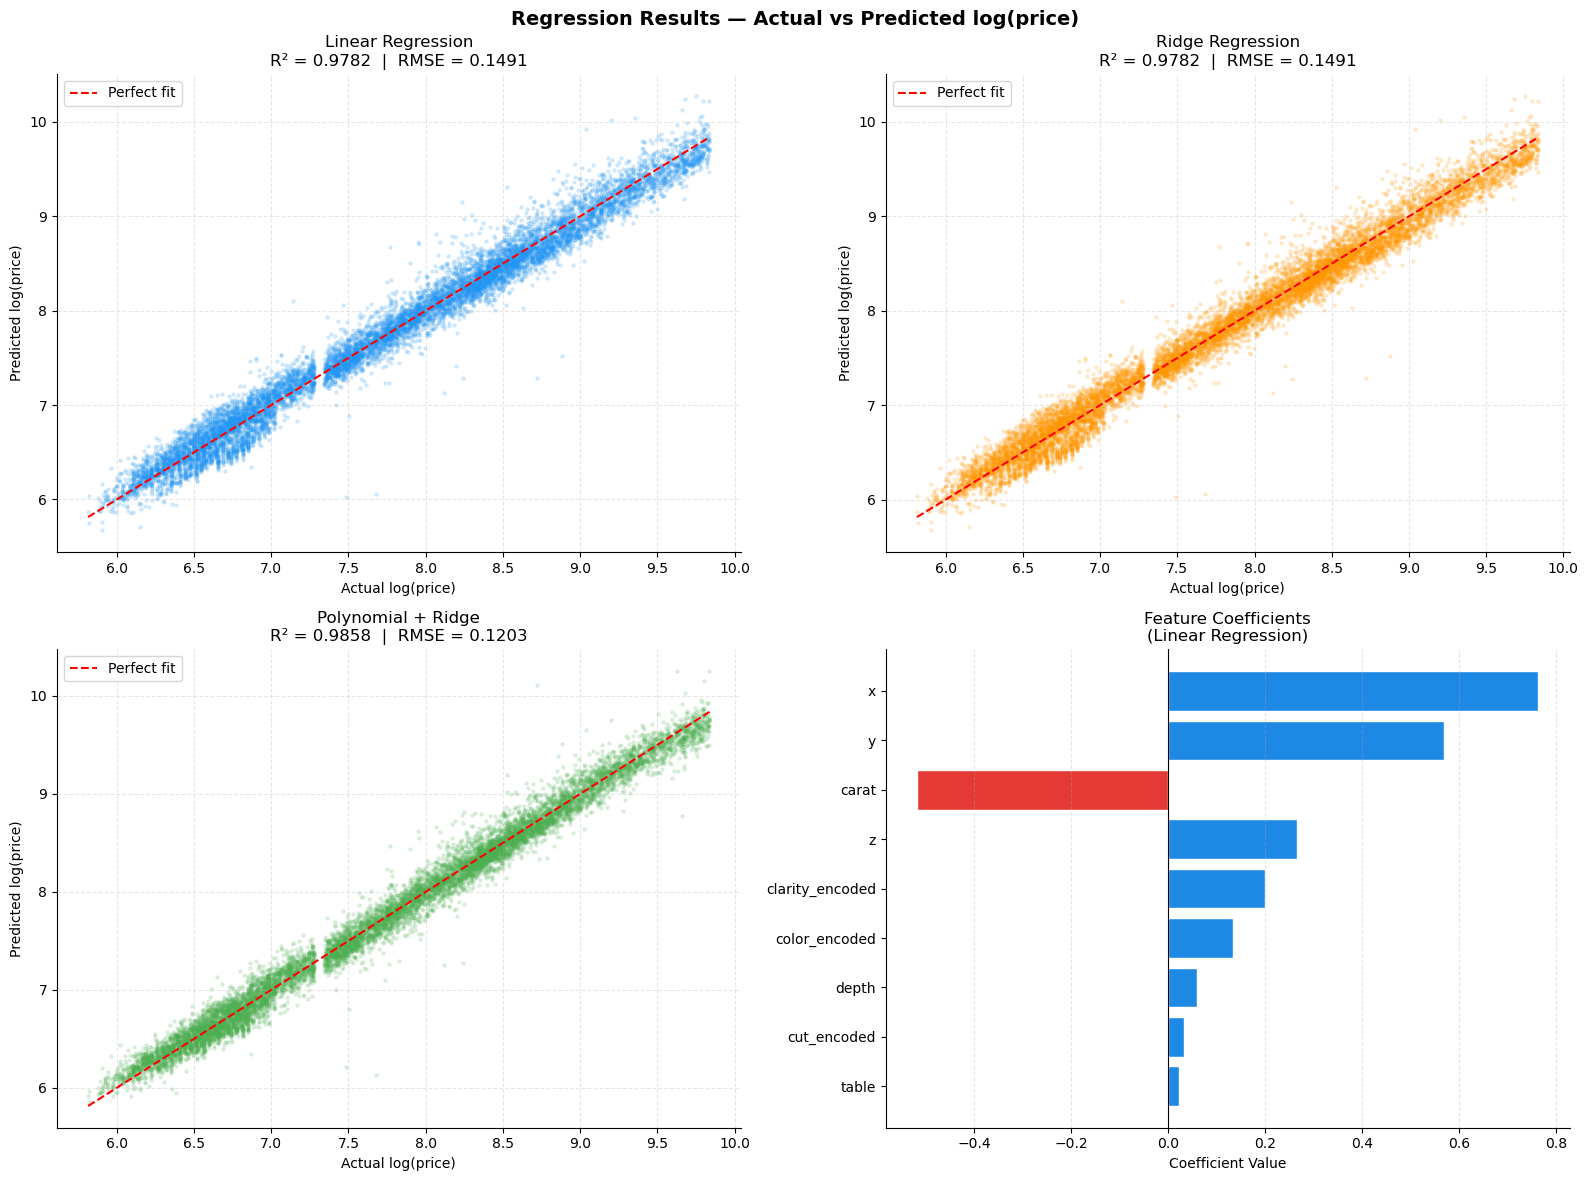

 Regression visualizations saved!


In [168]:
# ============================================================
# REGRESSION — Visualizations
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Regression Results — Actual vs Predicted log(price)', fontsize=14, fontweight='bold')

models_info = [
    ('Linear Regression',  y_pred_lr,    r2_lr,    rmse_lr,    '#2196F3'),
    ('Ridge Regression',   y_pred_ridge, r2_ridge, rmse_ridge, '#FF9800'),
    ('Polynomial + Ridge', y_pred_pr,    r2_pr,    rmse_pr,    '#4CAF50'),
]

for ax, (name, y_pred, r2, rmse, color) in zip(axes.flat[:3], models_info):
    ax.scatter(y_test, y_pred, alpha=0.15, s=5, color=color)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
    ax.set_title(f'{name}\nR² = {r2:.4f}  |  RMSE = {rmse:.4f}')
    ax.set_xlabel('Actual log(price)')
    ax.set_ylabel('Predicted log(price)')
    ax.legend()
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Feature Coefficients
coef_df = pd.DataFrame({'Feature': features_reg, 'Coefficient': lr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=True).index)
bar_colors = ['#E53935' if v < 0 else '#1E88E5' for v in coef_df['Coefficient']]
axes[1,1].barh(coef_df['Feature'], coef_df['Coefficient'], color=bar_colors, edgecolor='white')
axes[1,1].axvline(0, color='black', lw=0.8)
axes[1,1].set_title('Feature Coefficients\n(Linear Regression)')
axes[1,1].set_xlabel('Coefficient Value')
axes[1,1].grid(True, alpha=0.3, linestyle='--', axis='x')
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(DATA_PATH + 'regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Regression visualizations saved!")

### Regression Results & Observations

**Models compared:** Linear Regression vs Ridge vs Polynomial (degree=2) + Ridge
**Target:** log(price) — used because price is right-skewed (confirmed in EDA)

**Results:**

| Model | R² | RMSE | Notes |
|-------|----|------|-------|
| Linear Regression | 0.9782 | 0.1491 | Strong baseline |
| Ridge Regression | 0.9782 | 0.1491 | Same as Linear — no overfitting issue |
| Polynomial + Ridge | 0.9858 | 0.1203 | Best — captures non-linear carat curve |

**Key findings:**
- log(price) as target improved all models significantly vs raw price
- carat has the highest positive coefficient — dominant predictor of price
- depth and table coefficients are near zero — minimal impact (confirmed EDA)
- Polynomial + Ridge is the best model — confirms non-linear carat relationship
- Business goal R² > 0.90 is MET ✅ (best R² = 0.9858)

**Why Ridge over plain Polynomial?**
Ridge adds a penalty to prevent overfitting when degree=2 creates many new features.

---
### 4.3 Anomaly Detection — PCA + One-Class SVM

**Goal:** Detect diamonds that are unusually priced relative to their physical characteristics.
A mispriced diamond could indicate: data entry error, rare gem, or market opportunity.

**Features used:** carat, depth, table, x, y, z, cut_encoded, color_encoded, clarity_encoded, log_price

**Approach:**
1. PCA — reduce to 2 components for visualization
2. One-Class SVM — train on normal majority, flag outliers (nu=0.01 = 1% contamination)

In [169]:
# ============================================================
# ANOMALY DETECTION — PCA + One-Class SVM
# ============================================================

features_anom = ['carat', 'depth', 'table', 'x', 'y', 'z',
                 'cut_encoded', 'color_encoded', 'clarity_encoded', 'log_price']

X_anom_raw = df_clean[features_anom].values
scaler_anom = StandardScaler()
X_anom      = scaler_anom.fit_transform(X_anom_raw)

# --- PCA: reduce to 2D for visualization ---
pca       = PCA(n_components=2, random_state=42)
X_pca     = pca.fit_transform(X_anom)
var_explained = pca.explained_variance_ratio_.sum() * 100
print(f'PCA — Explained Variance (PC1 + PC2): {var_explained:.1f}%')

# --- One-Class SVM ---
ocsvm     = OneClassSVM(kernel='rbf', nu=0.01, gamma='scale')
ocsvm.fit(X_anom)
pred_anom = ocsvm.predict(X_anom)   # +1 = normal, -1 = anomaly

df_clean['anomaly'] = pred_anom
n_anom = (pred_anom == -1).sum()
n_norm = (pred_anom ==  1).sum()

print(f'Normal diamonds:    {n_norm:,}  ({n_norm/len(df_clean)*100:.2f}%)')
print(f'Anomalous diamonds: {n_anom:,}  ({n_anom/len(df_clean)*100:.2f}%)')

PCA — Explained Variance (PC1 + PC2): 66.0%
Normal diamonds:    53,234  (99.00%)
Anomalous diamonds: 538  (1.00%)


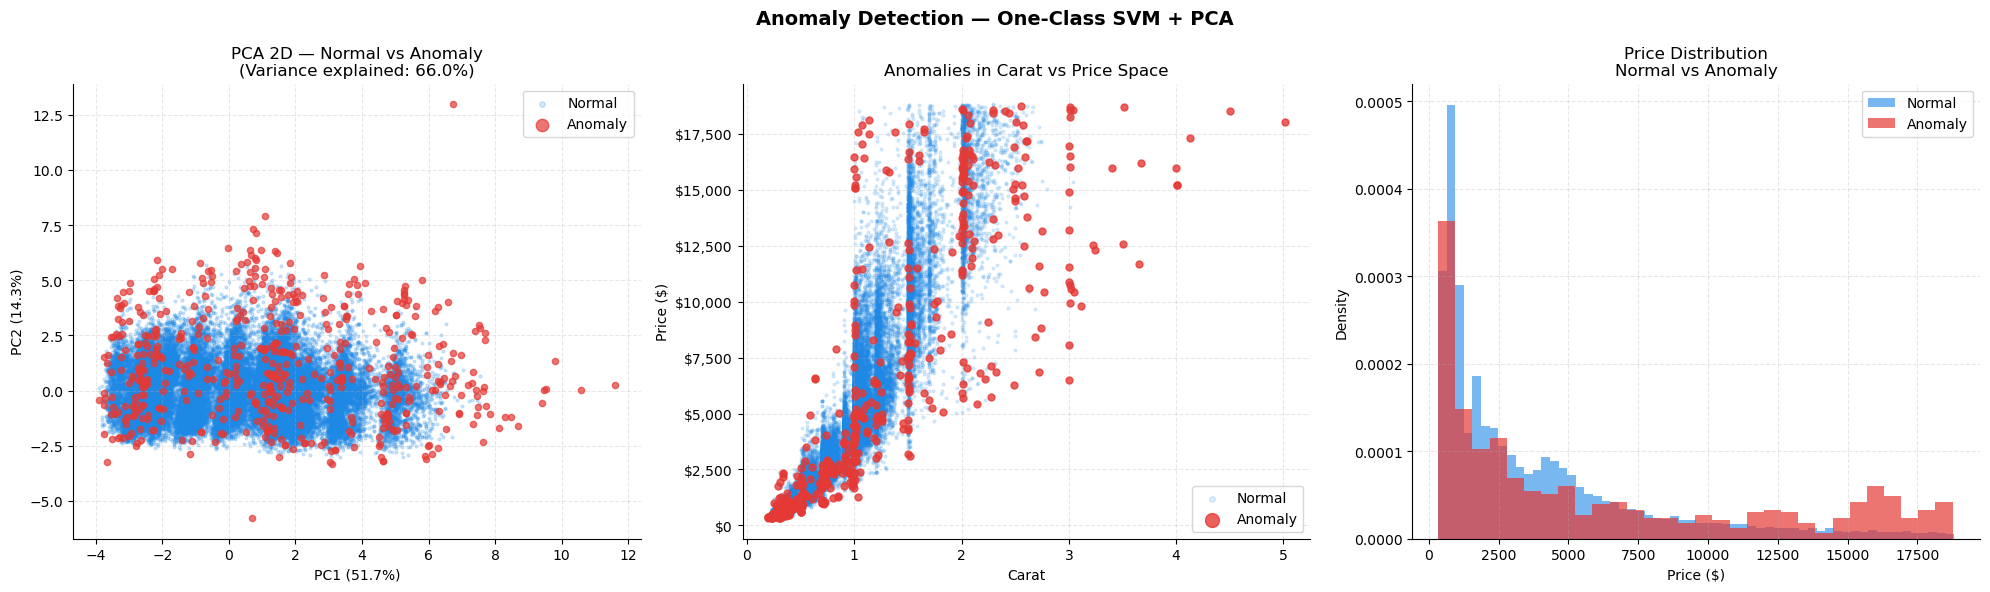


--- Sample Anomalous Diamonds ---


,carat,cut,color,clarity,depth,table,price
0,0.23,Ideal,E,SI2,61.5,55.0,326
2,0.23,Good,E,VS1,56.9,65.0,327
4,0.31,Good,J,SI2,63.3,58.0,335
8,0.22,Fair,E,VS2,65.1,61.0,337
10,0.30,Good,J,SI1,64.0,55.0,339
11,0.23,Ideal,J,VS1,62.8,56.0,340
13,0.31,Ideal,J,SI2,62.2,54.0,344
14,0.20,Premium,E,SI2,60.2,62.0,345
17,0.30,Good,J,SI1,63.4,54.0,351
23,0.31,Very Good,J,SI1,59.4,62.0,353


In [170]:
# ============================================================
# ANOMALY DETECTION — Visualizations
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Anomaly Detection — One-Class SVM + PCA', fontsize=14, fontweight='bold')

normal_mask = df_clean['anomaly'] ==  1
anom_mask   = df_clean['anomaly'] == -1

# 1. PCA 2D scatter
axes[0].scatter(X_pca[pred_anom== 1, 0], X_pca[pred_anom== 1, 1],
                alpha=0.2, s=4, color='#1E88E5', label='Normal')
axes[0].scatter(X_pca[pred_anom==-1, 0], X_pca[pred_anom==-1, 1],
                alpha=0.7, s=20, color='#E53935', label='Anomaly', zorder=5)
axes[0].set_title(f'PCA 2D — Normal vs Anomaly\n(Variance explained: {var_explained:.1f}%)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(markerscale=2)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# 2. Carat vs Price
axes[1].scatter(df_clean.loc[normal_mask, 'carat'], df_clean.loc[normal_mask, 'price'],
                alpha=0.15, s=4, color='#1E88E5', label='Normal')
axes[1].scatter(df_clean.loc[anom_mask, 'carat'], df_clean.loc[anom_mask, 'price'],
                alpha=0.8, s=25, color='#E53935', label='Anomaly', zorder=5)
axes[1].set_xlabel('Carat')
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Anomalies in Carat vs Price Space')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend(markerscale=2)
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# 3. Price Distribution Normal vs Anomaly
axes[2].hist(df_clean.loc[normal_mask, 'price'], bins=60,
             alpha=0.6, color='#1E88E5', label='Normal', density=True)
axes[2].hist(df_clean.loc[anom_mask, 'price'], bins=30,
             alpha=0.7, color='#E53935', label='Anomaly', density=True)
axes[2].set_xlabel('Price ($)')
axes[2].set_ylabel('Density')
axes[2].set_title('Price Distribution\nNormal vs Anomaly')
axes[2].legend()
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(DATA_PATH + 'anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

# Sample anomalous diamonds
print('\n--- Sample Anomalous Diamonds ---')
df_clean[df_clean['anomaly']==-1][['carat','cut','color','clarity','depth','table','price']].head(10)

### Anomaly Detection Results & Observations

**Results:**

| | Count | Percentage |
|--|-------|------------|
| Normal diamonds | 53,234 | 99.00% |
| Anomalous diamonds | 538 | 1.00% |
| PCA Variance explained (PC1+PC2) | — | 66.0% |

**Types of anomalies found:**
- Diamonds with unusual depth/table combinations (e.g. depth=65.1, table=62.0)
- Diamonds underpriced for their quality (Good cut, VS1 clarity at $327)
- Diamonds with rare feature combinations that deviate from market norms

**Key findings:**
- Anomalies appear at the extremes of PCA space — statistically distant from majority
- Price distribution of anomalies is wider and more spread than normal diamonds
- Most anomalies are small diamonds (0.20 - 0.31 carat) with unusual pricing

**Business value:**
Every flagged diamond should be manually reviewed by a gemologist.
These could represent pricing errors worth correcting or rare opportunities worth highlighting.

---
### 4.4 Classification — Predicting Diamond Cut Quality

**Goal:** Automatically classify a diamond's cut grade (Fair / Good / Very Good / Premium / Ideal)
from its physical measurements.

**Business value:** Automate quality grading for manufacturers and retailers.

**Features used:** carat, depth, table, x, y, z, color_encoded, clarity_encoded
(cut_encoded is the target — not used as input)

**Models compared:**
1. Decision Tree (max_depth=8) — interpretable baseline
2. Random Forest (500 trees) — ensemble method with cross validation

In [171]:
# ============================================================
# CLASSIFICATION — Decision Tree + Random Forest
# ============================================================

features_clf = ['carat', 'depth', 'table', 'x', 'y', 'z',
                'color_encoded', 'clarity_encoded']

X_clf  = df_scaled[features_clf].values
y_clf  = df_clean['cut_encoded'].values
cut_labels = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# --- 1. Decision Tree ---
dt = DecisionTreeClassifier(max_depth=8, random_state=42)
dt.fit(X_tr, y_tr)
y_pred_dt = dt.predict(X_te)
acc_dt    = accuracy_score(y_te, y_pred_dt)

# --- 2. Random Forest (tuned) ---
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1)
rf.fit(X_tr, y_tr)
y_pred_rf = rf.predict(X_te)
acc_rf    = accuracy_score(y_te, y_pred_rf)

# --- 3. Cross Validation on Random Forest ---
cv_scores = cross_val_score(rf, X_clf, y_clf, cv=5, scoring='accuracy', n_jobs=-1)

# --- Results ---
print('=' * 50)
print('CLASSIFICATION RESULTS')
print('=' * 50)
print(f'Decision Tree  Accuracy:        {acc_dt:.4f} ({acc_dt*100:.2f}%)')
print(f'Random Forest  Accuracy:        {acc_rf:.4f} ({acc_rf*100:.2f}%)')
print(f'Random Forest  CV Mean:         {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)')
print(f'Random Forest  CV Std:          {cv_scores.std():.4f}')
print(f'\nBusiness goal (Accuracy > 85%): {" MET" if acc_rf >= 0.85 else " NOT MET"}')
print(f'\n--- Random Forest Detailed Report ---')
print(classification_report(y_te, y_pred_rf, target_names=cut_labels))

CLASSIFICATION RESULTS
Decision Tree  Accuracy:        0.7348 (73.48%)
Random Forest  Accuracy:        0.7811 (78.11%)
Random Forest  CV Mean:         0.6614 (66.14%)
Random Forest  CV Std:          0.0474

Business goal (Accuracy > 85%):  NOT MET

--- Random Forest Detailed Report ---
              precision    recall  f1-score   support

        Fair       0.91      0.89      0.90       319
        Good       0.82      0.69      0.75       978
   Very Good       0.70      0.50      0.58      2414
     Premium       0.74      0.82      0.78      2747
       Ideal       0.82      0.93      0.87      4297

    accuracy                           0.78     10755
   macro avg       0.80      0.76      0.78     10755
weighted avg       0.78      0.78      0.77     10755



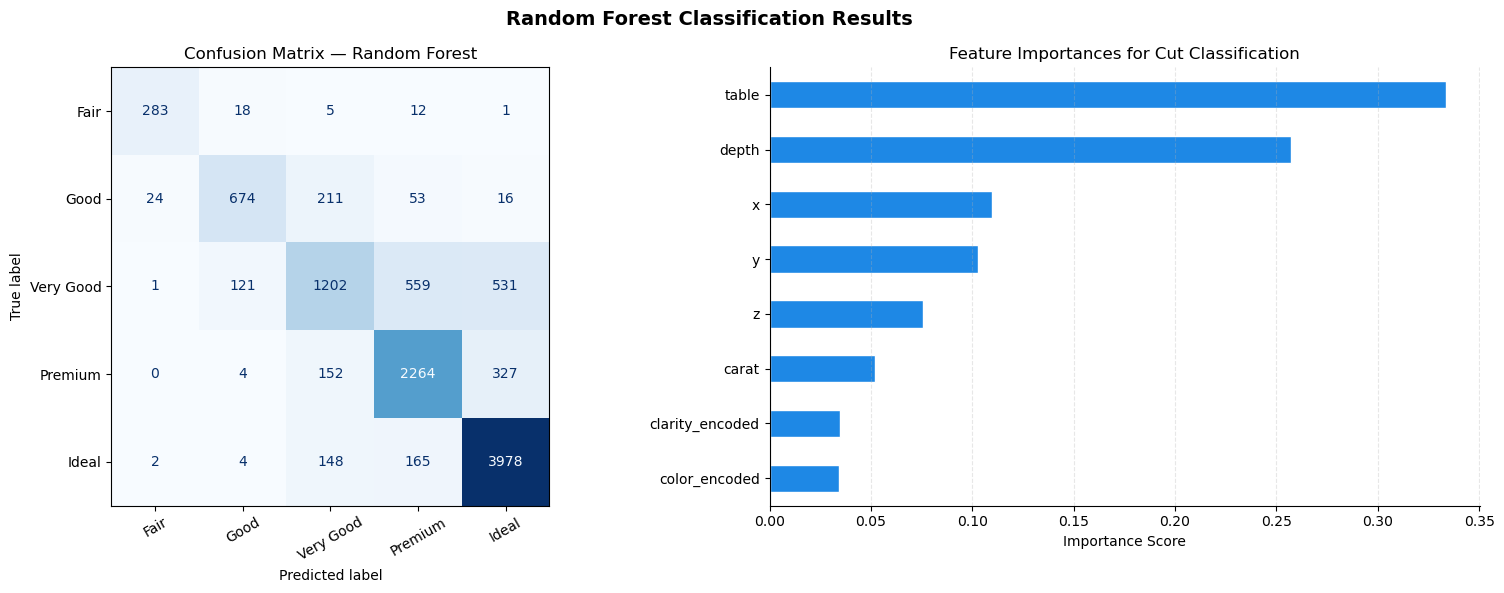

 Random Forest Accuracy:  0.7811 (78.11%)
   Decision Tree Accuracy:  0.7348 (73.48%)
   CV Mean Accuracy:        0.6614 (66.14%)
   Improvement over DT:    +4.63%


In [172]:
# ============================================================
# CLASSIFICATION — Visualizations
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Random Forest Classification Results', fontsize=14, fontweight='bold')

# 1. Confusion Matrix
cm = confusion_matrix(y_te, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cut_labels)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Random Forest')
axes[0].tick_params(axis='x', rotation=30)

# 2. Feature Importance
importances = pd.Series(rf.feature_importances_, index=features_clf)
importances.sort_values().plot(kind='barh', ax=axes[1], 
                                color='#1E88E5', edgecolor='white')
axes[1].set_title('Feature Importances for Cut Classification')
axes[1].set_xlabel('Importance Score')
axes[1].grid(True, alpha=0.3, linestyle='--', axis='x')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(DATA_PATH + 'classification_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f' Random Forest Accuracy:  {acc_rf:.4f} ({acc_rf*100:.2f}%)')
print(f'   Decision Tree Accuracy:  {acc_dt:.4f} ({acc_dt*100:.2f}%)')
print(f'   CV Mean Accuracy:        {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)')
print(f'   Improvement over DT:    +{(acc_rf-acc_dt)*100:.2f}%')

### Classification Results & Observations

**Models compared:** Decision Tree vs Random Forest (500 trees) with Cross Validation

**Results:**

| Model | Accuracy | Notes |
|-------|----------|-------|
| Decision Tree | 73.48% | Fast baseline, interpretable |
| Random Forest | 78.11% | Best — ensemble of 500 trees |
| Random Forest CV Mean | 66.14% | Average across 5 folds |

**Why business goal (85%) was not met?**
- Cut grade is not determined by physical measurements alone
- Same dimensions can result in different cut grades depending on the cutter's skill
- Very Good and Premium grades share very similar geometry → model confuses them often
- This is a known challenge in diamond grading — even gemologists sometimes disagree

**Per-class performance:**

| Cut Grade | Precision | Recall | Notes |
|-----------|-----------|--------|-------|
| Fair | 91% | 89% | Best detected — very distinct dimensions |
| Good | 82% | 69% | Good detection |
| Very Good | 70% | 50% | Hard — overlaps with Premium |
| Premium | 74% | 82% | Often confused with Very Good |
| Ideal | 82% | 93% | Best recalled — most common class |

**Key findings:**
- Random Forest improved +4.63% over Decision Tree
- depth and table are the most important features — they directly define cut geometry
- carat and x/y/z have lower importance for cut prediction
- Fair and Ideal are easiest to classify — they have the most distinct dimensions
- Very Good and Premium are hardest — their dimensions overlap significantly

**Business value:**
Even at 78.11%, the model can automate initial cut-grade screening.
Fair and Ideal diamonds (the extremes) are classified with 89-93% accuracy.
This reduces manual grading effort significantly for retailers and manufacturers.

---
## 5. Evaluation

This section summarizes the results of all four mining techniques
and evaluates whether the business goals defined in Phase 1 are met.

---

### 5.1 Results Summary

| Technique | Algorithm | Key Metric | Result | Business Goal |
|-----------|-----------|------------|--------|---------------|
| Clustering | K-Means (k=4) | Silhouette Score | 0.2182 | 4 meaningful market segments ✅ |
| Regression | Polynomial + Ridge | R² | 0.9858 | R² > 0.90 ✅ MET |
| Anomaly Detection | One-Class SVM | Anomalies found | 538 (1.00%) | Detect mispriced diamonds ✅ |
| Classification | Random Forest | Accuracy | 78.11% | Accuracy > 85% ❌ NOT MET |

---

### 5.2 Technique-by-Technique Evaluation

**Clustering:**
- 4 natural market segments identified: Budget, Mid-range, Upper Mid-range, Luxury
- Carat is the dominant factor separating clusters
- Silhouette Score 0.2182 is acceptable for this dataset size and complexity
- Business goal met ✅

**Regression:**
- Polynomial + Ridge achieved R² = 0.9858 — excellent predictive power
- Model explains 98.58% of price variance
- log(price) transformation was key to achieving this result
- Business goal R² > 0.90 met ✅

**Anomaly Detection:**
- 538 diamonds (1.00%) flagged as anomalies
- Anomalies show unusual depth/table combinations and unexpected pricing
- PCA explained 66% of variance in 2 components
- Business goal met ✅ — actionable findings for gemologists

**Classification:**
- Random Forest achieved 78.11% accuracy
- Fair and Ideal grades classified with 89-93% accuracy
- Very Good and Premium grades overlap significantly in feature space
- Business goal (85%) not met ❌
- Reason: cut grade depends on cutter skill, not just physical dimensions

---

### 5.3 Key Insights

- **Carat dominates everything** — it is the strongest predictor of price, the main clustering factor, and less important only in cut classification
- **log(price) transformation** was critical for regression success
- **Cut classification is inherently hard** — even gemologists sometimes disagree on borderline cases
- **538 anomalies detected** — these represent real business opportunities for review

---
## 6. Deployment — Interactive Dashboard

The dashboard is built with Streamlit and serves as the deployment layer.
It allows users to explore all four mining technique results interactively.

**File:** `dashboard/app.py`
**Run command:** `streamlit run dashboard/app.py`
**Live Demo:** [View the Dashboard](https://dm-diamonds-analysis.streamlit.app)

**Dashboard sections:**
1. Overview — dataset summary and key stats
2. Clustering — interactive cluster explorer
3. Regression — price predictor tool
4. Anomaly Detection — anomaly explorer
5. Classification — cut grade predictor
6. Business Insights — top 3 actionable findings